# Priority-branch results explorer

Analyse the counterfactuals produced by the priority branch (`runner.py`: MINLP + random-search baseline).

- **Part 1 - Selection**: pick a dataset, view the initial samples, then choose one CF method and one sample.
- **Part 2 - Sample analysis**: inspect the chosen sample and the counterfactual(s) the selected method generated for it, plotted over the dataset background, plus how those CF predictions compare to the target. The **priority score** of each CF is shown.
- **Part 3 - Method metrics**: compare every method on sparsity, proximity, validity, **priority score** and more.

Plot conventions mirror `standard_methods/results_explorer.ipynb`: continuous features use histograms, categorical features use category bars, and the target is the model prediction (an approximate `prediction` distribution over the training set is used as the background).

## Part 1 - Selection

Select a results dataset and load it. The initial samples used for the run are shown below.

In [ ]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ipywidgets as widgets
from IPython.display import display, clear_output

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'explainit').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp._context import load_context

RESULTS_ROOT = (PROJECT_ROOT / 'explainit' / 'experiments' / 'continuous_minlp'
                / 'priority_methods' / 'results')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

STATE = {}
_CTX_CACHE = {}

def get_context(dataset_key):
    if dataset_key not in _CTX_CACHE:
        _CTX_CACHE[dataset_key] = load_context(dataset_key)
    return _CTX_CACHE[dataset_key]

def current():
    if not STATE:
        raise RuntimeError('Select a dataset and click Load first.')
    return STATE

def scolor(i):
    return plt.get_cmap('tab10')(i % 10)

def available_result_datasets():
    if not RESULTS_ROOT.is_dir():
        return []
    # Result layout: results/<dataset_key>/<priority_set>/samples.csv
    return sorted({p.parent.parent.name for p in RESULTS_ROOT.rglob('samples.csv')
                   if p.parent.parent.parent == RESULTS_ROOT})

def available_sets_for_dataset(dataset_key):
    rdir = RESULTS_ROOT / dataset_key
    if not rdir.is_dir():
        return []
    return sorted([p.name for p in rdir.iterdir() if (p / 'samples.csv').exists()])

def logical_value(vec, name):
    if name in STATE['numerical_index']:
        return float(vec[STATE['numerical_index'][name]])
    g = STATE['categorical_groups'][name]
    sub = [vec[i] for i in g['indices']]
    return int(np.argmax(sub))

def cat_label(name, code):
    code = int(code)
    cats = STATE['categorical_groups'][name].get('categories')
    if cats and 0 <= code < len(cats):
        return str(cats[code])
    return str(code)

def build_state(dataset_key, set_name=None):
    if set_name is None:
        sets = available_sets_for_dataset(dataset_key)
        set_name = sets[0] if sets else None
    if set_name is None:
        raise RuntimeError(f'No result sets found for dataset {dataset_key!r}.')
    rdir = RESULTS_ROOT / dataset_key / set_name
    samples_df = pd.read_csv(rdir / 'samples.csv')
    cfs_df = pd.read_csv(rdir / 'counterfactuals.csv')
    summary_df = pd.read_csv(rdir / 'metrics_summary.csv')
    run_config = json.loads((rdir / 'run_config.json').read_text())
    feature_names = list(run_config['feature_names'])
    numerical_features = list(run_config['numerical_features'])
    categorical_groups = dict(run_config['categorical_groups'])
    epsilon = float(run_config['epsilon'])
    priority_set = run_config.get('priority_set')
    target_col = 'prediction'

    ctx = get_context(dataset_key)
    X_train = np.asarray(ctx.X_train, dtype=float)
    # Model predictions on the training set form the target-axis background.
    y_train = np.asarray(ctx.model.predict(X_train, verbose=0)).reshape(-1)
    numerical_index = {n: feature_names.index(n) for n in numerical_features}

    STATE.clear()
    STATE.update(dict(dataset_key=dataset_key, samples_df=samples_df, cfs_df=cfs_df,
                      summary_df=summary_df, run_config=run_config, feature_names=feature_names,
                      numerical_features=numerical_features, categorical_groups=categorical_groups,
                      epsilon=epsilon, priority_set=priority_set, target_col=target_col,
                      numerical_index=numerical_index, X_train=X_train, y_train=y_train))

    logical = list(numerical_features) + list(categorical_groups.keys())
    default_kinds = {n: 'continuous' for n in numerical_features}
    for n in categorical_groups:
        default_kinds[n] = 'categorical'
    default_kinds[target_col] = 'continuous'
    STATE['display_feature_names'] = logical + [target_col]
    STATE['default_kinds'] = default_kinds

    rows = []
    for r in range(len(X_train)):
        vec = X_train[r]
        row = {n: logical_value(vec, n) for n in logical}
        row[target_col] = float(y_train[r])
        rows.append(row)
    STATE['disp_df'] = pd.DataFrame(rows)
    STATE['methods'] = sorted(cfs_df['method'].unique())
    STATE['sample_ids'] = list(samples_df['sample_id'])
    return STATE

_ds = available_result_datasets()
dataset_dd = widgets.Dropdown(options=_ds, value=(_ds[0] if _ds else None), description='Dataset:')
_sets0 = available_sets_for_dataset(_ds[0]) if _ds else []
set_dd = widgets.Dropdown(options=_sets0, value=(_sets0[0] if _sets0 else None), description='Set:')
load_btn = widgets.Button(description='Load results', button_style='primary')
load_out = widgets.Output()

def _on_dataset_change(_=None):
    sets = available_sets_for_dataset(dataset_dd.value)
    set_dd.options = sets
    if sets:
        set_dd.value = sets[0]
dataset_dd.observe(_on_dataset_change, names='value')

def _on_load(_=None):
    with load_out:
        clear_output(wait=True)
        if not dataset_dd.value:
            print('No result datasets found. Run priority_methods/runner.py first.')
            return
        if not set_dd.value:
            print('No result sets available for this dataset.')
            return
        build_state(dataset_dd.value, set_dd.value)
        dk = STATE['dataset_key']; ps = STATE['priority_set']; nm = len(STATE['samples_df']); ms = STATE['methods']
        print(f"Loaded dataset={dk} | priority_set={ps} | samples={nm} | methods={ms}")
        print('Initial samples:')
        display(STATE['samples_df'].round(3))

display(widgets.HBox([dataset_dd, set_dd, load_btn]))
display(load_out)
load_btn.on_click(_on_load)
if _ds and set_dd.value:
    _on_load()

2026-07-06 09:09:46,876 - DEBUG - tensorflow - Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-07-06 09:09:47,194 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-06 09:09:47,194 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-06 09:09:47,194 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-06 09:09:47,195 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-06 09:09:47,832 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-07-06 09:09:47,833 - DEBUG - matplotlib.pyplot - Loaded backend inline version unknown.


Output()

Choose **one CF method** and **one sample** to analyse, then click *Use selection*. Part 2 analyses the counterfactual(s) this method generated for that sample.

In [2]:
st = current()
method_dd = widgets.Dropdown(options=st['methods'], description='Method:')
sample_dd = widgets.Dropdown(options=st['sample_ids'], description='Sample:')
use_btn = widgets.Button(description='Use selection', button_style='primary')
sel_out = widgets.Output()

def _on_use(_=None):
    with sel_out:
        clear_output(wait=True)
        STATE['sel_sample'] = int(sample_dd.value)
        STATE['sel_method'] = str(method_dd.value)
        sid = STATE['sel_sample']; mth = STATE['sel_method']
        sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == mth)]
        real = sub[sub['cf_prediction'].notna()]
        n_cf = len(real); n_valid = int(real['validity'].sum()) if n_cf else 0
        print(f'Selected method={mth}, sample_id={sid}')
        print(f'  {n_cf} counterfactual(s) generated for this sample ({n_valid} valid).')
        print('Now run the Part 2 cells below.')

display(widgets.HBox([method_dd, sample_dd, use_btn]))
display(sel_out)
use_btn.on_click(_on_use)
_on_use()

Output()

## Part 2 - Sample analysis

Analyse the selected sample and the counterfactual(s) the **selected method** generated for it. The table lists the original sample followed by each counterfactual (`cf_index`), including its `priority_score`. Below, those CFs are plotted over the dataset background, and finally their predictions are compared to the target.

In [3]:
st = current()
sid = STATE.get('sel_sample'); mth = STATE.get('sel_method')
if sid is None:
    print('Run the Part 1 selection cell first.')
else:
    fn = st['feature_names']
    srow = st['samples_df'][st['samples_df']['sample_id'] == sid].iloc[0]
    rows = []
    base = {f: srow[f] for f in fn}
    base.update({'cf_index': 'ORIG', 'prediction': srow['original_prediction'],
                 'target': srow['target'], 'validity': '', 'priority_score': '',
                 'abs_pred_error': 0.0, 'l1': 0.0, 'l2': 0.0, 'n_changed': 0})
    rows.append(base)
    sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == mth)]
    sub = sub.sort_values('cf_index')
    for _, r in sub.iterrows():
        d = {f: r['cf__' + f] for f in fn}
        d.update({'cf_index': r['cf_index'], 'prediction': r['cf_prediction'],
                  'target': r['target'], 'validity': r['validity'],
                  'priority_score': r['priority_score'],
                  'abs_pred_error': r['abs_pred_error'], 'l1': r['l1'], 'l2': r['l2'],
                  'n_changed': r['n_changed']})
        rows.append(d)
    cols = ['cf_index', 'prediction', 'target', 'validity', 'priority_score',
            'abs_pred_error', 'l1', 'l2', 'n_changed'] + fn
    tbl = pd.DataFrame(rows)[cols]
    n_real = int(sub['cf_prediction'].notna().sum())
    print(f'Sample {sid} - method: {mth} ({n_real} counterfactual(s))')
    display(tbl.round(3))

Sample 60 - method: minlp (1 counterfactual(s))


,cf_index,prediction,target,validity,priority_score,abs_pred_error,l1,l2,n_changed,age,sex=0,sex=1,bmi,bp,s1,s2,s3,s4,s5,s6
0,ORIG,0.414,0.114,,,0.000,0.000,0.000,0,-0.543,1.0,0.0,0.608,-0.142,1.738,1.951,-0.354,1.484,0.666,0.024
1,0,0.049,0.114,False,5.199216,0.064,14.287,6.419,9,0.021,1.0,0.0,0.608,-0.141,0.643,-2.356,-1.506,0.389,-2.663,2.768


### 1D distribution

Pick a feature (or the target). Continuous features show a histogram; categorical features show category bars. The sample value and the CF value(s) are overlaid. Enable *all methods* to compare every method's CF.

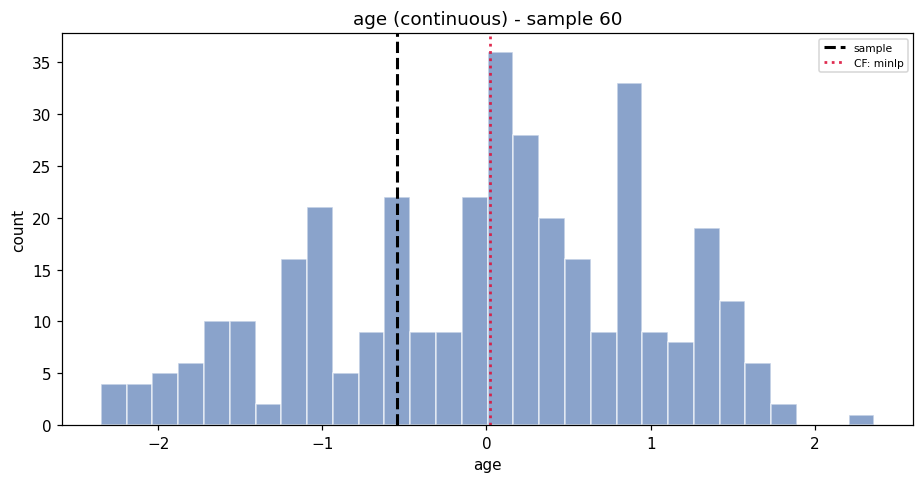

In [ ]:
st = current()

def _sample_vec(sid):
    srow = st['samples_df'][st['samples_df']['sample_id'] == sid].iloc[0]
    return np.array([srow[f] for f in st['feature_names']], dtype=float), srow

def _cf_vecs(sid, method):
    sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == method)]
    sub = sub.sort_values('cf_index')
    out = []
    for _, r in sub.iterrows():
        vec = np.array([r['cf__' + f] for f in st['feature_names']], dtype=float)
        if np.any(pd.isna(vec)):
            continue
        out.append((vec, r))
    return out

def _feat_axis_value(feature, vec, rec, is_sample):
    if feature == st['target_col']:
        return float(rec['original_prediction'] if is_sample else rec['cf_prediction'])
    return logical_value(vec, feature)

def plot_1d(feature, kind, bins, logy, show_all):
    sid = STATE['sel_sample']; mth = STATE['sel_method']
    disp = st['disp_df']; tcol = st['target_col']
    svec, srow = _sample_vec(sid)
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    cat_to_x = {}
    if kind == 'continuous':
        vals = pd.to_numeric(disp[feature], errors='coerce').dropna().values
        ax.hist(vals, bins=bins, color='#4C72B0', alpha=0.65, edgecolor='white')
    else:
        counts = disp[feature].value_counts().sort_index()
        cat_to_x = {c: i for i, c in enumerate(counts.index)}
        xpos = np.arange(len(counts))
        ax.bar(xpos, counts.values, color='#55A868', alpha=0.85)
        ax.set_xticks(xpos)
        ax.set_xticklabels([cat_label(feature, c) for c in counts.index])
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel(feature); ax.set_ylabel('count')
    ymax = ax.get_ylim()[1]
    methods_to_plot = st['methods'] if show_all else [mth]
    sx = _feat_axis_value(feature, svec, srow, True)
    if kind == 'continuous':
        ax.axvline(sx, color='black', ls='--', lw=2, label='sample')
        for i, m in enumerate(methods_to_plot):
            col = scolor(i) if show_all else 'crimson'
            for j, (cvec, r) in enumerate(_cf_vecs(sid, m)):
                cx = _feat_axis_value(feature, cvec, r, False)
                ax.axvline(cx, color=col, ls=':', lw=1.8, alpha=0.9,
                           label=(f'CF: {m}' if j == 0 else None))
        if feature == tcol:
            tgt = float(srow['target']); eps = st['epsilon']
            ax.axvspan(tgt - eps, tgt + eps, color='green', alpha=0.12, label='target band')
            ax.axvline(tgt, color='green', lw=1.5, label='target')
    else:
        scode = int(sx)
        if scode in cat_to_x:
            ax.scatter([cat_to_x[scode]], [ymax * 0.96], color='black', marker='v', s=100, zorder=5, label='sample')
        for i, m in enumerate(methods_to_plot):
            col = scolor(i) if show_all else 'crimson'
            for j, (cvec, r) in enumerate(_cf_vecs(sid, m)):
                ccode = int(logical_value(cvec, feature))
                if ccode in cat_to_x:
                    ax.scatter([cat_to_x[ccode]], [ymax * (0.90 - 0.03 * i - 0.02 * j)],
                               color=col, marker='o', s=70, zorder=5,
                               label=(f'CF: {m}' if j == 0 else None))
    ax.legend(fontsize=7)
    ax.set_title(f'{feature} ({kind}) - sample {sid}')
    plt.tight_layout(); plt.show()

_feats = st['display_feature_names']
feat_dd = widgets.Dropdown(options=_feats, value=_feats[0], description='Feature:')
kind_dd = widgets.Dropdown(options=['continuous', 'categorical'],
                           value=st['default_kinds'][_feats[0]], description='Kind:')
bins_sl = widgets.IntSlider(value=30, min=5, max=80, step=5, description='Bins:')
logy_cb = widgets.Checkbox(value=False, description='log y')
all_cb = widgets.Checkbox(value=False, description='all methods')
plot_btn = widgets.Button(description='Plot', button_style='primary')
feat_dd.observe(lambda ch: setattr(kind_dd, 'value', st['default_kinds'][feat_dd.value]), names='value')

def _redraw_1d(make_plot=False):
    clear_output(wait=True)
    display(widgets.HBox([feat_dd, kind_dd]))
    display(widgets.HBox([bins_sl, logy_cb, all_cb, plot_btn]))
    if make_plot:
        plot_1d(feat_dd.value, kind_dd.value, bins_sl.value, logy_cb.value, all_cb.value)

plot_btn.on_click(lambda _=None: _redraw_1d(make_plot=True))
_redraw_1d(make_plot=False)

### 2D distribution

Plot two features against each other with the dataset in the background. Two continuous features use a 2D histogram; if either axis is categorical the dataset is shown as a jittered scatter with labelled category ticks. The sample (black X) is connected to each CF; when the target is on an axis its valid band is shaded green.

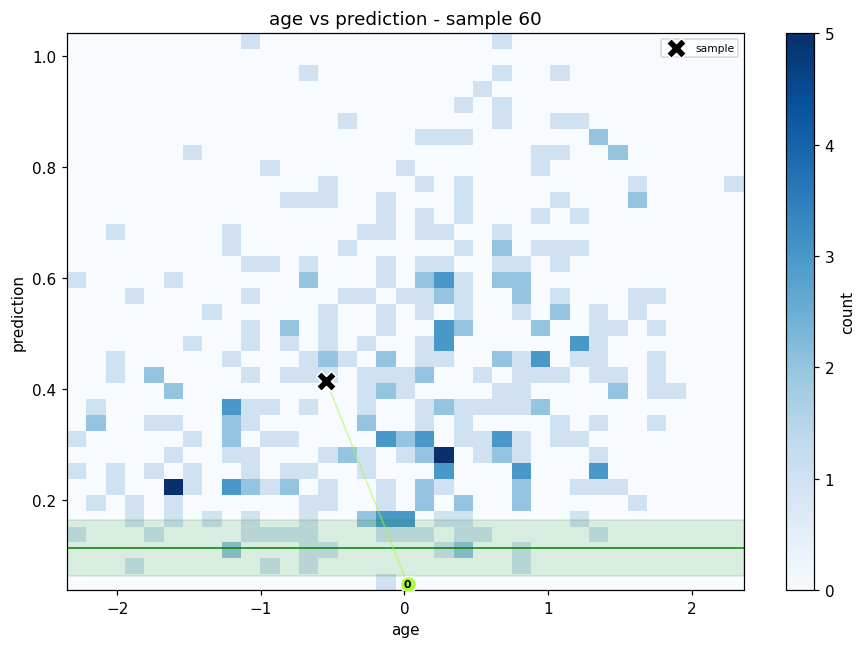

In [ ]:
st = current()

def _cf_idx(r):
    try:
        return int(r['cf_index'])
    except Exception:
        return None

def _build_cf_color_map(sid, methods_to_plot, cmap_name='turbo'):
    keys = []
    for m in methods_to_plot:
        for _, r in _cf_vecs(sid, m):
            idx = _cf_idx(r)
            if idx is not None:
                keys.append((m, idx))
    keys = sorted(set(keys), key=lambda x: (x[1], x[0]))
    cmap = plt.get_cmap(cmap_name)
    if len(keys) <= 1:
        return {k: cmap(0.5) for k in keys}
    return {k: cmap(i / (len(keys) - 1)) for i, k in enumerate(keys)}

def _text_color(col):
    r, g, b = col[:3]
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if lum > 0.55 else 'white'

def plot_2d(fx, kx, fy, ky, bins, logc, show_all):
    sid = STATE['sel_sample']; mth = STATE['sel_method']
    disp = st['disp_df']; tcol = st['target_col']
    svec, srow = _sample_vec(sid)
    bx = pd.to_numeric(disp[fx], errors='coerce').values
    by = pd.to_numeric(disp[fy], errors='coerce').values
    fig, ax = plt.subplots(figsize=(8.5, 6))
    if kx == 'continuous' and ky == 'continuous':
        m = ~np.isnan(bx) & ~np.isnan(by)
        h = ax.hist2d(bx[m], by[m], bins=bins, cmap='Blues', norm=LogNorm() if logc else None)
        fig.colorbar(h[3], ax=ax, label='count')
    else:
        rng = np.random.default_rng(0)
        jx = 0.06 if kx == 'categorical' else 0.0
        jy = 0.06 if ky == 'categorical' else 0.0
        ax.scatter(bx + rng.normal(0, jx, size=len(bx)), by + rng.normal(0, jy, size=len(by)),
                   s=10, c='#CCCCCC', label='dataset', zorder=1)
        if kx == 'categorical':
            codes = sorted({int(v) for v in bx if not np.isnan(v)})
            ax.set_xticks(codes); ax.set_xticklabels([cat_label(fx, c) for c in codes])
        if ky == 'categorical':
            codes = sorted({int(v) for v in by if not np.isnan(v)})
            ax.set_yticks(codes); ax.set_yticklabels([cat_label(fy, c) for c in codes])
    sxx = _feat_axis_value(fx, svec, srow, True); syy = _feat_axis_value(fy, svec, srow, True)
    ax.scatter([sxx], [syy], marker='X', s=170, c='black', edgecolors='white', zorder=6, label='sample')
    methods_to_plot = st['methods'] if show_all else [mth]
    cf_color_map = _build_cf_color_map(sid, methods_to_plot, cmap_name='turbo')
    for i, m in enumerate(methods_to_plot):
        for j, (cvec, r) in enumerate(_cf_vecs(sid, m)):
            cf_idx = _cf_idx(r)
            col = cf_color_map.get((m, cf_idx), plt.get_cmap('turbo')(0.0))
            cxx = _feat_axis_value(fx, cvec, r, False); cyy = _feat_axis_value(fy, cvec, r, False)
            ax.plot([sxx, cxx], [syy, cyy], color=col, alpha=0.5, lw=1.1, zorder=4)
            ax.scatter([cxx], [cyy], s=110, color=col, edgecolors='white', zorder=7)
            if cf_idx is not None:
                ax.text(cxx, cyy, str(cf_idx), ha='center', va='center',
                        fontsize=7, color=_text_color(col), fontweight='bold', zorder=8)
    eps = st['epsilon']; tgt = float(srow['target'])
    if fx == tcol:
        ax.axvspan(tgt - eps, tgt + eps, color='green', alpha=0.12); ax.axvline(tgt, color='green', lw=1)
    if fy == tcol:
        ax.axhspan(tgt - eps, tgt + eps, color='green', alpha=0.12); ax.axhline(tgt, color='green', lw=1)
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.legend(fontsize=7)
    ax.set_title(f'{fx} vs {fy} - sample {sid}')
    plt.tight_layout(); plt.show()

_feats2 = st['display_feature_names']
fx_dd = widgets.Dropdown(options=_feats2, value=_feats2[0], description='X:')
kx_dd = widgets.Dropdown(options=['continuous', 'categorical'], value=st['default_kinds'][_feats2[0]], description='X kind:')
fy_dd = widgets.Dropdown(options=_feats2, value=_feats2[-1], description='Y:')
ky_dd = widgets.Dropdown(options=['continuous', 'categorical'], value=st['default_kinds'][_feats2[-1]], description='Y kind:')
bins2_sl = widgets.IntSlider(value=35, min=5, max=80, step=5, description='Bins:')
logc_cb = widgets.Checkbox(value=False, description='log scale')
all2_cb = widgets.Checkbox(value=False, description='all methods')
plot2_btn = widgets.Button(description='Plot', button_style='primary')
fx_dd.observe(lambda ch: setattr(kx_dd, 'value', st['default_kinds'][fx_dd.value]), names='value')
fy_dd.observe(lambda ch: setattr(ky_dd, 'value', st['default_kinds'][fy_dd.value]), names='value')

def _redraw_2d(make_plot=False):
    clear_output(wait=True)
    display(widgets.HBox([fx_dd, kx_dd]))
    display(widgets.HBox([fy_dd, ky_dd]))
    display(widgets.HBox([bins2_sl, logc_cb, all2_cb, plot2_btn]))
    if make_plot:
        plot_2d(fx_dd.value, kx_dd.value, fy_dd.value, ky_dd.value, bins2_sl.value, logc_cb.value, all2_cb.value)

plot2_btn.on_click(lambda _=None: _redraw_2d(make_plot=True))
_redraw_2d(make_plot=False)

### CF predictions vs target (and priority score)

For the selected sample, each counterfactual of the **selected method** is shown against the desired target (green line) and its valid band (shaded), with the original prediction as a dashed reference. Bars are green when the CF is valid, grey otherwise. The companion table lists each CF's distance from the target and its `priority_score`.

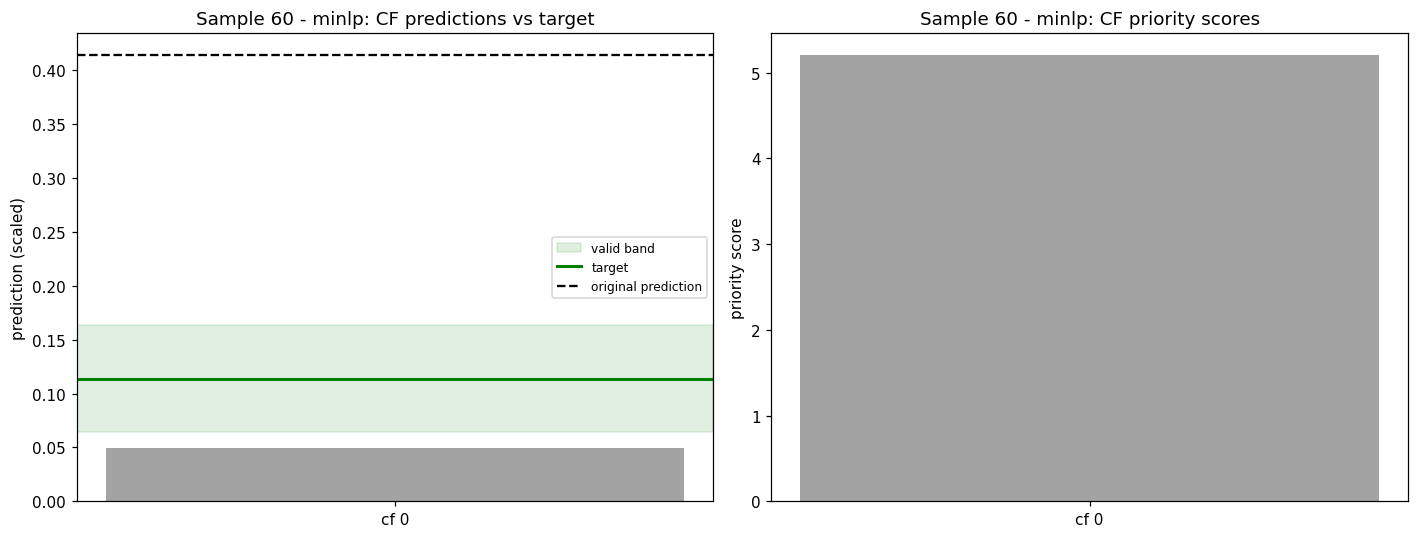

Distance of each CF prediction from target (sorted), with priority score:


,cf_index,cf_prediction,target,abs_pred_error,priority_score,l1,n_changed,validity
0,0,0.0495,0.114,0.0645,5.1992,14.2869,9,False


In [6]:
st = current(); sid = STATE['sel_sample']; mth = STATE['sel_method']
srow = st['samples_df'][st['samples_df']['sample_id'] == sid].iloc[0]
tgt = float(srow['target']); op = float(srow['original_prediction']); eps = st['epsilon']
sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == mth)].copy()
sub = sub[sub['cf_prediction'].notna()].sort_values('cf_index')
if not len(sub):
    print(f'Method {mth} produced no counterfactual for sample {sid}.')
else:
    labels = [f'cf {int(i)}' for i in sub['cf_index']]
    preds = list(sub['cf_prediction'])
    colors = ['#2E8B57' if bool(v) else '#999999' for v in sub['validity']]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    xpos = np.arange(len(labels))
    axes[0].bar(xpos, preds, color=colors, alpha=0.9)
    axes[0].axhspan(tgt - eps, tgt + eps, color='green', alpha=0.12, label='valid band')
    axes[0].axhline(tgt, color='green', lw=2, label='target')
    axes[0].axhline(op, color='black', ls='--', lw=1.5, label='original prediction')
    axes[0].set_xticks(xpos); axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('prediction (scaled)')
    axes[0].set_title(f'Sample {sid} - {mth}: CF predictions vs target')
    axes[0].legend(fontsize=8)
    axes[1].bar(xpos, list(sub['priority_score']), color=colors, alpha=0.9)
    axes[1].set_xticks(xpos); axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('priority score')
    axes[1].set_title(f'Sample {sid} - {mth}: CF priority scores')
    plt.tight_layout(); plt.show()
    dist = sub[['cf_index', 'cf_prediction', 'target', 'abs_pred_error', 'priority_score',
                'l1', 'n_changed', 'validity']].copy()
    dist = dist.sort_values('abs_pred_error')
    print('Distance of each CF prediction from target (sorted), with priority score:')
    display(dist.round(4))

## Part 3 - Method metrics

Compare every CF method across the whole run. The first grid shows per-method aggregates from `metrics_summary.csv` (validity, proximity, sparsity, prediction error, **priority score**, runtime, iterations). The second grid shows per-CF distributions from `counterfactuals.csv`, including the priority score. Averages are computed over **valid** counterfactuals.

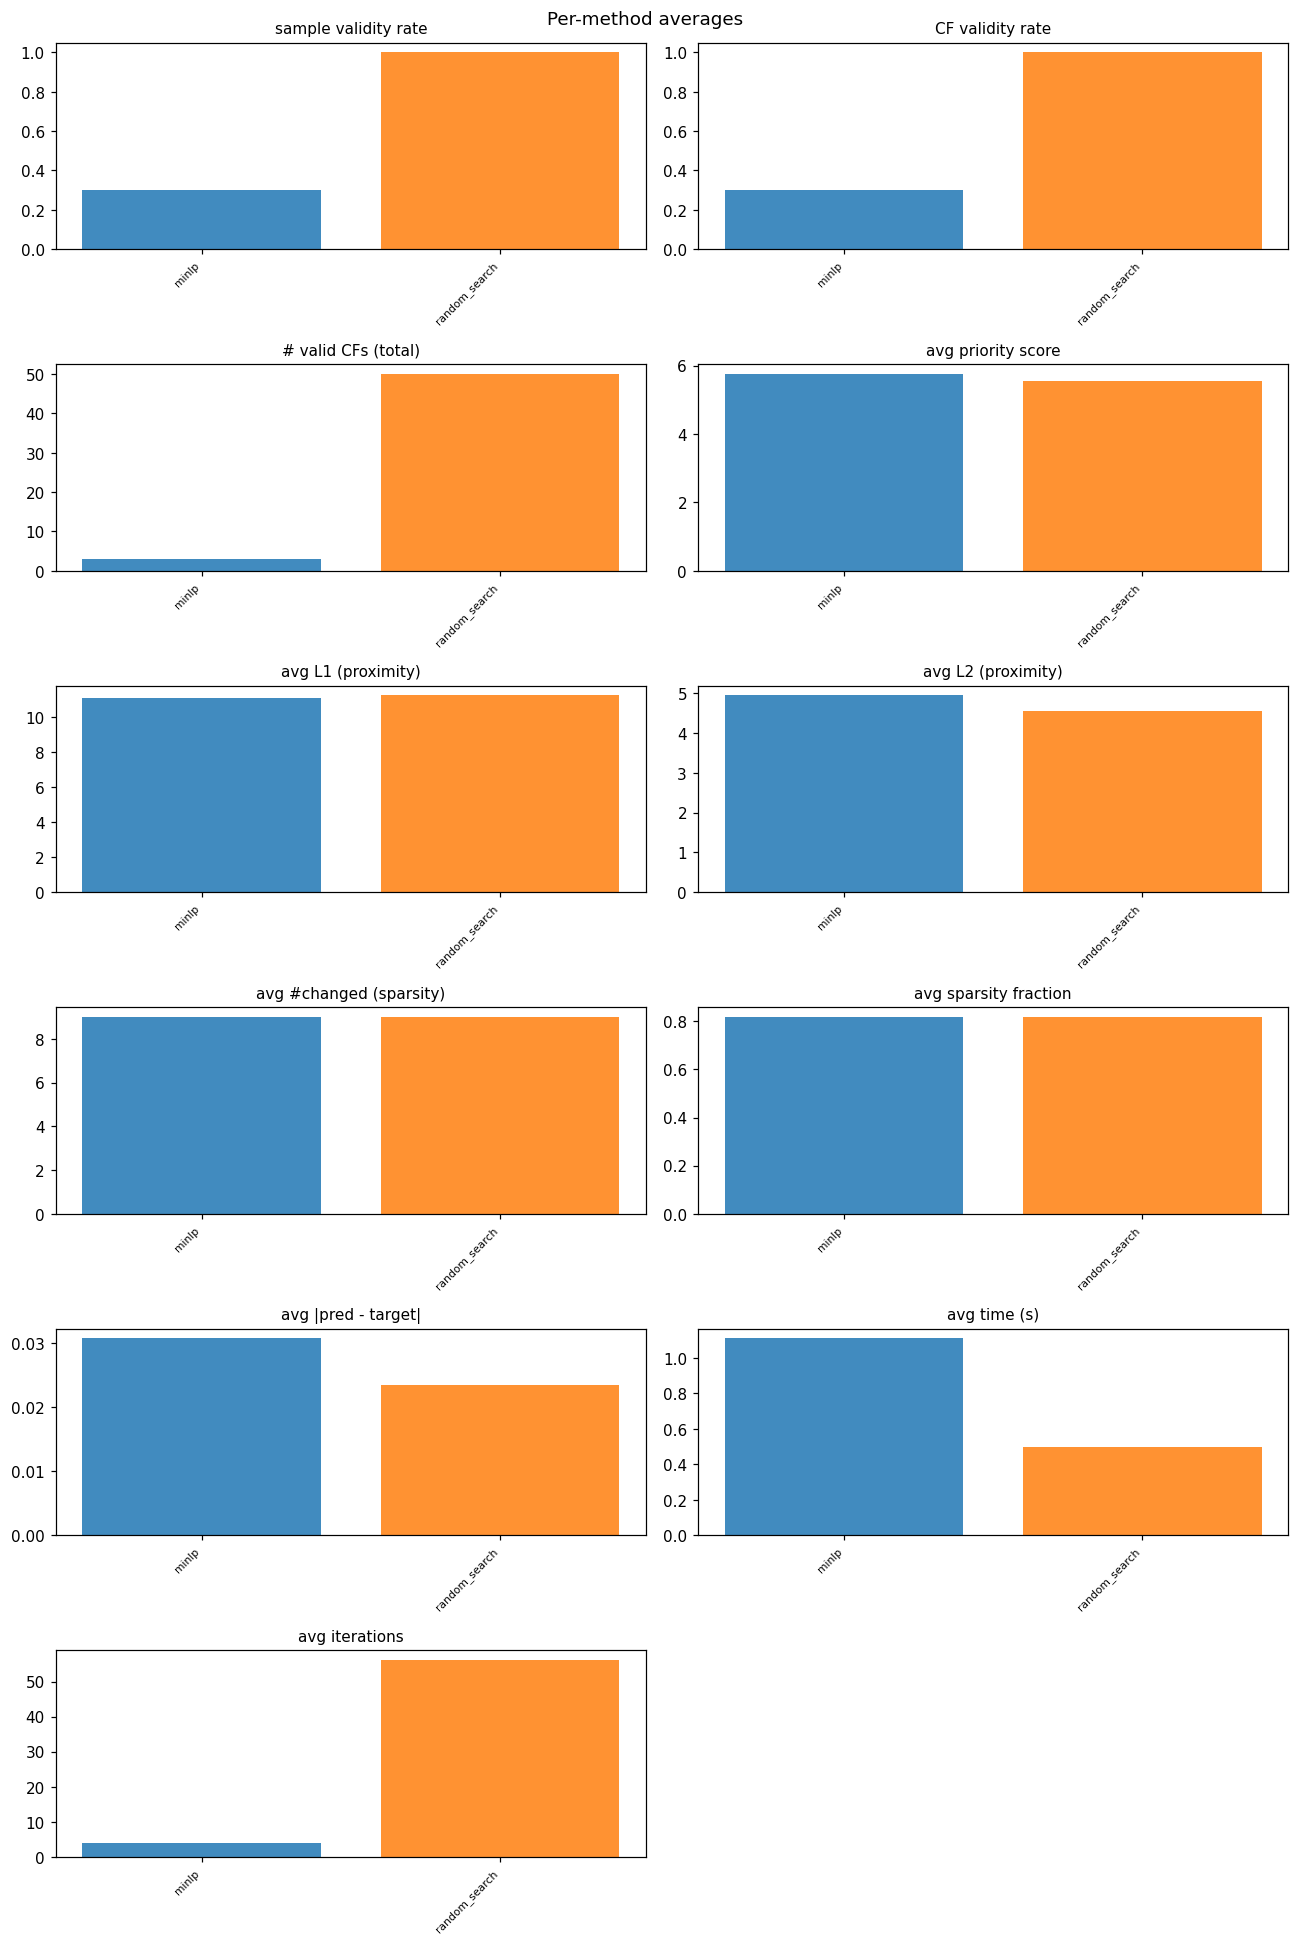

In [7]:
st = current(); summary = st['summary_df']
methods = list(summary['method'])
metrics = [('sample_validity_rate', 'sample validity rate'), ('cf_validity_rate', 'CF validity rate'),
           ('n_cfs_valid', '# valid CFs (total)'), ('avg_priority_score', 'avg priority score'),
           ('avg_l1', 'avg L1 (proximity)'), ('avg_l2', 'avg L2 (proximity)'),
           ('avg_n_changed', 'avg #changed (sparsity)'), ('avg_sparsity_fraction', 'avg sparsity fraction'),
           ('avg_abs_pred_error', 'avg |pred - target|'), ('avg_time_seconds', 'avg time (s)'),
           ('avg_iterations', 'avg iterations')]
cols = 2; rows = int(np.ceil(len(metrics) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.0 * rows))
axes = np.atleast_1d(axes).ravel()
xpos = np.arange(len(methods))
for ax, (key, title) in zip(axes, metrics):
    ax.bar(xpos, summary[key].values, color=[scolor(i) for i in range(len(methods))], alpha=0.85)
    ax.set_xticks(xpos); ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
for j in range(len(metrics), len(axes)):
    axes[j].axis('off')
fig.suptitle('Per-method averages', fontsize=12)
plt.tight_layout(); plt.show()

/var/folders/r0/18mc62gx7gd4f4f2t45c76cr0000gn/T/ipykernel_47558/3495353886.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)
/var/folders/r0/18mc62gx7gd4f4f2t45c76cr0000gn/T/ipykernel_47558/3495353886.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)
/var/folders/r0/18mc62gx7gd4f4f2t45c76cr0000gn/T/ipykernel_47558/3495353886.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)
/var/folders/r0/18mc62gx7gd4f4f2t45c76cr0000gn/T/ipykernel_47558/3495353886.py:11: Matplotl

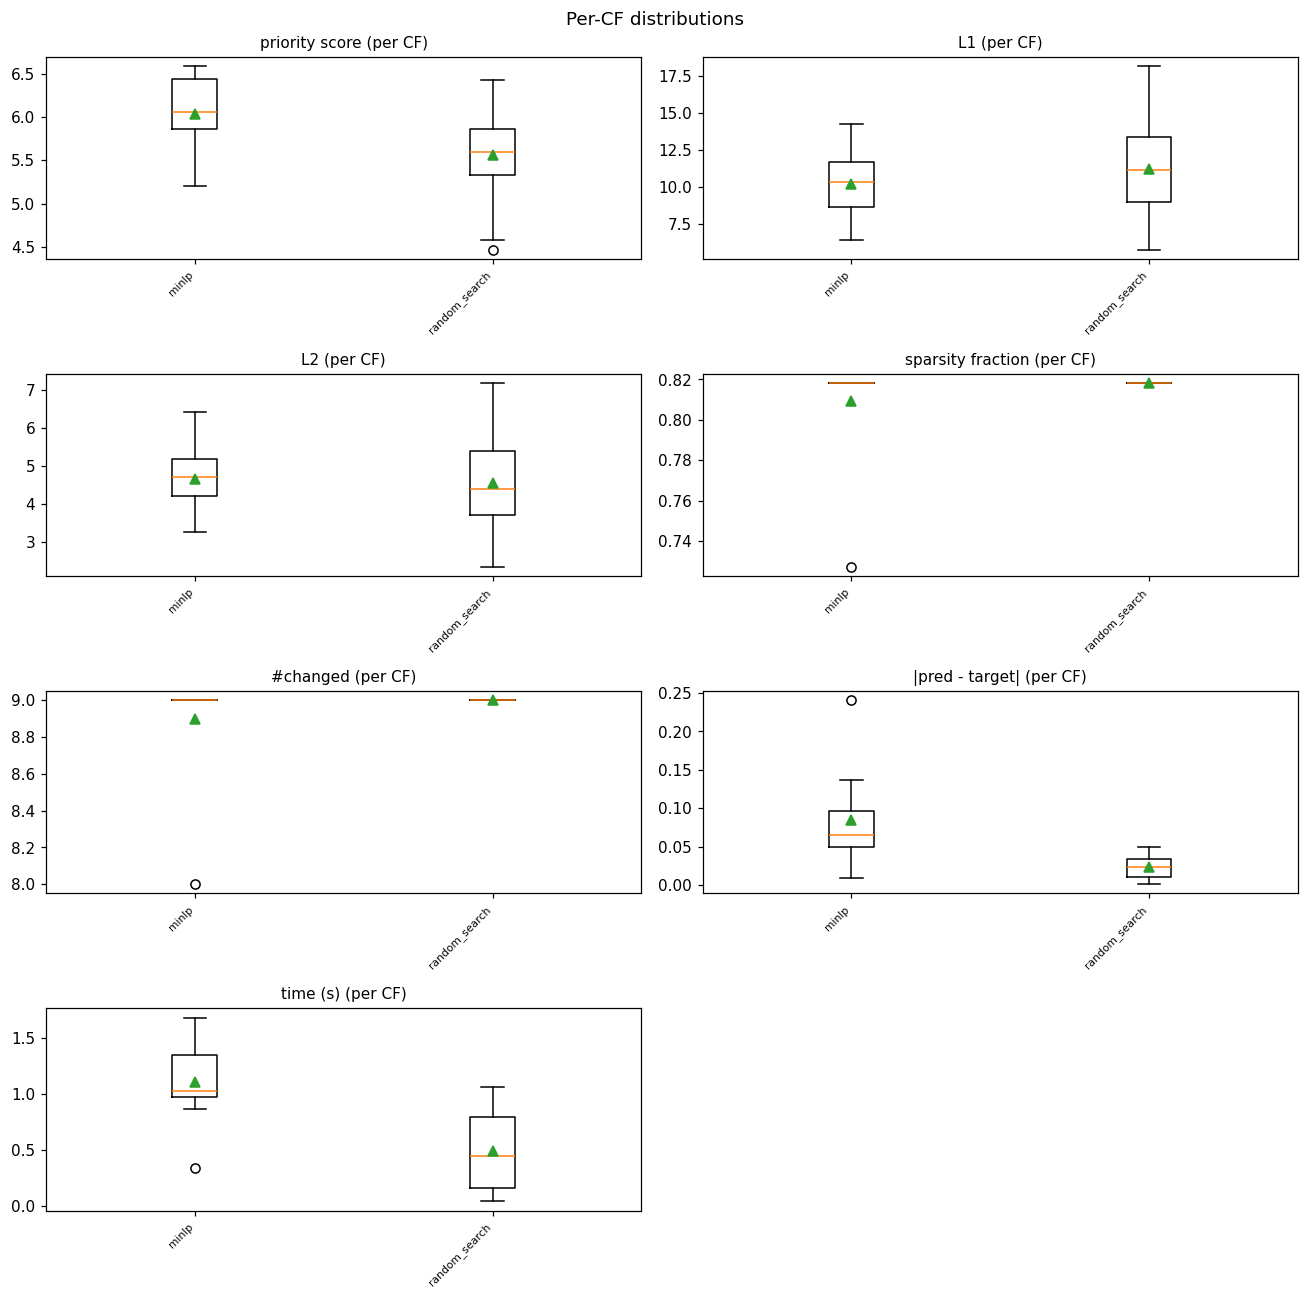

In [8]:
st = current(); cfs = st['cfs_df']; methods = st['methods']
dist_metrics = [('priority_score', 'priority score'), ('l1', 'L1'), ('l2', 'L2'),
                ('sparsity_fraction', 'sparsity fraction'), ('n_changed', '#changed'),
                ('abs_pred_error', '|pred - target|'), ('time_seconds', 'time (s)')]
cols = 2; rows = int(np.ceil(len(dist_metrics) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.0 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, (key, title) in zip(axes, dist_metrics):
    data = [cfs[cfs['method'] == m][key].dropna().values for m in methods]
    data = [d if len(d) else np.array([np.nan]) for d in data]
    ax.boxplot(data, labels=methods, showmeans=True)
    ax.set_title(title + ' (per CF)', fontsize=10)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_ha('right'); lbl.set_fontsize(7)
for j in range(len(dist_metrics), len(axes)):
    axes[j].axis('off')
fig.suptitle('Per-CF distributions', fontsize=12)
plt.tight_layout(); plt.show()

## Part 4 - Holistic overview

View every sample across **all priority sets** for the loaded dataset.
Select a method below, then:
- The **validity matrix** shows which samples are valid for that method in each
  priority set (green = True, red = False).
- The **failure table** shows for each sample and each set how many valid CFs
  were obtained and, if none, the failure reason.

In [9]:
st = current()
dk = st['dataset_key']
all_sets = available_sets_for_dataset(dk)
methods = st['methods']

# Build a dict: set_name -> {'cfs': DataFrame, 'samples': DataFrame, 'run_config': dict}
all_results = {}
for sn in all_sets:
    sdir = RESULTS_ROOT / dk / sn
    all_results[sn] = {
        'cfs': pd.read_csv(sdir / 'counterfactuals.csv'),
        'samples': pd.read_csv(sdir / 'samples.csv'),
        'config': json.loads((sdir / 'run_config.json').read_text()),
    }

set_names = list(all_results.keys())
if not methods:
    print('No methods loaded.')
elif not set_names:
    print('No result sets available.')
else:
    print(f'Dataset: {dk} | available sets: {set_names} | methods: {methods}')
    print('Use the dropdown below and then run the next cells.')

Dataset: diabetes | available sets: ['set1', 'set2'] | methods: ['minlp', 'random_search']
Use the dropdown below and then run the next cells.


In [10]:
methods = st['methods']
p4_method_dd = widgets.Dropdown(options=methods, value=methods[0], description='Method:')
display(p4_method_dd)

Dropdown(description='Method:', options=('minlp', 'random_search'), value='minlp')

In [11]:
method = p4_method_dd.value
set_names = list(all_results.keys())
# Build per-set per-sample validity: use the first set's samples as the index
ref = all_results[set_names[0]]['samples']
validity_rows = []
for _, srow in ref.iterrows():
    sid = srow['sample_id']
    row = {'sample_id': sid,
           'target': srow['target'],
           'original_prediction': srow['original_prediction']}
    for sn in set_names:
        sub = all_results[sn]['cfs']
        sub = sub[(sub['sample_id'] == sid) & (sub['method'] == method)]
        row[sn + '_valid'] = sub['validity'].any() if len(sub) > 0 else False
    validity_rows.append(row)

validity_df = pd.DataFrame(validity_rows).set_index('sample_id')
validity_cols = [sn + '_valid' for sn in set_names]

def _color_valid(val):
    if isinstance(val, bool):
        return 'background-color: #4CAF50; color: white' if val else 'background-color: #F44336; color: white'
    return ''

styled = validity_df[validity_cols + ['target', 'original_prediction']].style \
    .applymap(_color_valid, subset=validity_cols) \
    .format({'target': '{:.4f}', 'original_prediction': '{:.4f}'})
print(f'Validity matrix — method: {method}')
display(styled)

Validity matrix — method: minlp


/var/folders/r0/18mc62gx7gd4f4f2t45c76cr0000gn/T/ipykernel_47558/332261177.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_color_valid, subset=validity_cols) \


,set1_valid,set2_valid,target,original_prediction
sample_id,,,,
60.000000,False,True,0.1140,0.4140
2.000000,True,True,0.2863,0.5863
52.000000,True,True,0.0185,0.3185
18.000000,False,False,0.3193,0.6193
27.000000,False,True,0.0429,0.3429
26.000000,True,True,0.3505,0.6505
38.000000,False,True,0.1236,0.4236
50.000000,False,True,0.1089,0.4089
24.000000,False,True,0.0792,0.3792


In [12]:
method = p4_method_dd.value
set_names = list(all_results.keys())
ref = all_results[set_names[0]]['samples']
failure_rows = []
for _, srow in ref.iterrows():
    sid = srow['sample_id']
    row = {'sample_id': sid}
    has_any_failure = False
    for sn in set_names:
        cfs = all_results[sn]['cfs']
        sub = cfs[(cfs['sample_id'] == sid) & (cfs['method'] == method)]
        n_requested = len(sub)
        n_valid = int(sub['validity'].sum()) if n_requested > 0 else 0
        row[sn + '_requested_cfs'] = n_requested
        row[sn + '_nr_valid_cfs'] = n_valid
        if n_requested > 0 and n_valid == 0 and 'failure_reason' in sub.columns:
            reasons = sub['failure_reason'].dropna().unique()
            row[sn + '_failure_reason'] = '; '.join(reasons) if len(reasons) > 0 else ''
        else:
            row[sn + '_failure_reason'] = ''
        if n_valid == 0:
            has_any_failure = True
    if has_any_failure or True:  # always include for visibility
        failure_rows.append(row)

failure_df = pd.DataFrame(failure_rows).set_index('sample_id')
print(f'Failure table — method: {method}')
display(failure_df)

Failure table — method: minlp


,set1_requested_cfs,set1_nr_valid_cfs,set1_failure_reason,set2_requested_cfs,set2_nr_valid_cfs,set2_failure_reason
sample_id,,,,,,
60.0,1,0,MINLP did not reach target: patience_exhausted,1,1,
2.0,1,1,,1,1,
52.0,1,1,,1,1,
18.0,1,0,MINLP did not reach target: patience_exhausted,1,0,MINLP did not reach target: patience_exhausted
27.0,1,0,MINLP did not reach target: patience_exhausted,1,1,
26.0,1,1,,1,1,
38.0,1,0,MINLP did not reach target: patience_exhausted,1,1,
50.0,1,0,MINLP did not reach target: max_iterations,1,1,
24.0,1,0,MINLP did not reach target: patience_exhausted,1,1,


## Part 5 - Set-level method comparison

Compare **MINLP vs random_search** for a chosen priority set. Two bar charts are
shown side by side:
- **Validity** — one bar per generated CF (green=valid, red=invalid).
- **Priority score** — one bar per generated CF, coloured by method.

Pick a set and run all cells below.

In [13]:
set_names = list(all_results.keys())
p5_set_dd = widgets.Dropdown(options=set_names, value=set_names[0], description='Set:')
display(p5_set_dd)

Dropdown(description='Set:', options=('set1', 'set2'), value='set1')

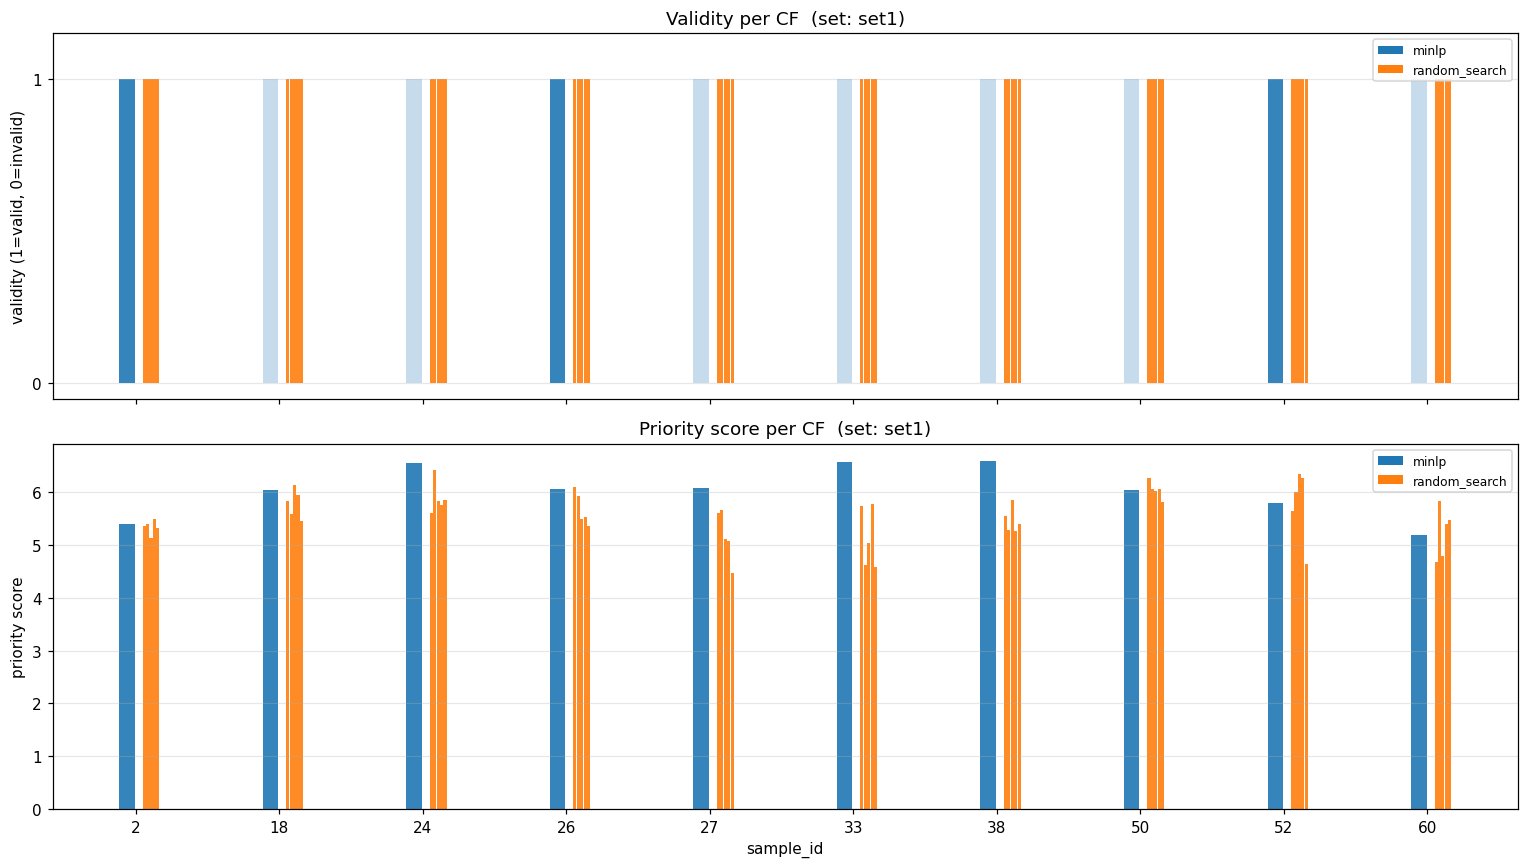

In [14]:
sn = p5_set_dd.value
cfs = all_results[sn]['cfs']
samples_df = all_results[sn]['samples']
methods = sorted(cfs['method'].unique())

# --- Data prep: one row per (sample_id, method, cf_index) ---
plot_data = cfs[['sample_id', 'method', 'cf_index', 'validity', 'priority_score']].copy()
# Convert validity to int for plotting: 1 = valid, 0 = invalid
plot_data['validity_int'] = plot_data['validity'].astype(int)
plot_data = plot_data.sort_values(['sample_id', 'method', 'cf_index'])

sample_ids = sorted(plot_data['sample_id'].unique())
n_samples = len(sample_ids)

# Colour maps for methods
method_colors = {m: plt.get_cmap('tab10')(i) for i, m in enumerate(methods)}

fig, (ax_valid, ax_score) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Validity subplot ---
# Place bars manually: each sample gets a group, within each group bars for
# each method side by side, one bar per CF.
bar_width = 0.12
x_centres = np.arange(n_samples)
n_methods = len(methods)
method_offsets = {}
for mi, m in enumerate(methods):
    m_cfs = cfs[cfs['method'] == m]
    max_cfs_per_sample = int(m_cfs.groupby('sample_id').size().max()) if len(m_cfs) > 0 else 1
    method_offsets[m] = max_cfs_per_sample

for mi, m in enumerate(methods):
    m_sub = plot_data[plot_data['method'] == m]
    max_cfs = method_offsets[m]
    col = method_colors[m]
    # Group bars per sample
    for si, sid in enumerate(sample_ids):
        rows = m_sub[m_sub['sample_id'] == sid]
        for ci, (_, r) in enumerate(rows.iterrows()):
            v = int(r['validity_int'])
            if v == 0:
                offset = (mi - (n_methods - 1) / 2) * bar_width + ci * bar_width / max_cfs
                x = x_centres[si] + offset
                ax_valid.bar(x, 1, bar_width / max_cfs * 0.9, color=col, alpha=0.25, edgecolor='none')

for mi, m in enumerate(methods):
    m_sub = plot_data[plot_data['method'] == m]
    max_cfs = method_offsets[m]
    col = method_colors[m]
    for si, sid in enumerate(sample_ids):
        rows = m_sub[m_sub['sample_id'] == sid]
        for ci, (_, r) in enumerate(rows.iterrows()):
            v = int(r['validity_int'])
            if v == 1:
                offset = (mi - (n_methods - 1) / 2) * bar_width + ci * bar_width / max_cfs
                x = x_centres[si] + offset
                ax_valid.bar(x, 1, bar_width / max_cfs * 0.9, color=col, alpha=0.9, edgecolor='none')

ax_valid.set_ylabel('validity (1=valid, 0=invalid)')
ax_valid.set_title(f'Validity per CF  (set: {sn})')
ax_valid.set_ylim(-0.05, 1.15)
ax_valid.set_yticks([0, 1])
ax_valid.set_xticks(x_centres)
ax_valid.grid(axis='y', alpha=0.3)
# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=method_colors[m], label=m) for m in methods]
ax_valid.legend(handles=legend_patches, fontsize=8)

# --- Priority score subplot ---
for mi, m in enumerate(methods):
    m_sub = plot_data[plot_data['method'] == m]
    max_cfs = method_offsets[m]
    col = method_colors[m]
    for si, sid in enumerate(sample_ids):
        rows = m_sub[m_sub['sample_id'] == sid]
        for ci, (_, r) in enumerate(rows.iterrows()):
            score = float(r['priority_score'])
            if not np.isnan(score):
                offset = (mi - (n_methods - 1) / 2) * bar_width + ci * bar_width / max_cfs
                x = x_centres[si] + offset
                ax_score.bar(x, score, bar_width / max_cfs * 0.9, color=col, alpha=0.9, edgecolor='none')

ax_score.set_xlabel('sample_id')
ax_score.set_ylabel('priority score')
ax_score.set_title(f'Priority score per CF  (set: {sn})')
ax_score.set_xticks(x_centres)
ax_score.set_xticklabels([str(int(s)) for s in sample_ids])
ax_score.grid(axis='y', alpha=0.3)
ax_score.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
p5_filter_dd = widgets.RadioButtons(
    options=['valid only', 'all'],
    value='valid only',
    description='Show:'
)
display(p5_filter_dd)

In [ ]:
filter_mode = p5_filter_dd.value
set_names = list(all_results.keys())
methods = ['minlp', 'random_search']

ref = all_results[set_names[0]]['samples']
sample_ids = sorted(ref['sample_id'].unique())
cols = [f'{m}_{sn}' for m in methods for sn in set_names]

# --- Build table with validity tracking ---
rows = []
validity_grid = {}  # (sample_id, col) -> bool|None
for sid in sample_ids:
    row = {'sample_id': int(sid)}
    for m in methods:
        for sn in set_names:
            cfs = all_results[sn]['cfs']
            sub = cfs[(cfs['sample_id'] == sid) & (cfs['method'] == m)]
            col = f'{m}_{sn}'
            if filter_mode == 'valid only':
                sub = sub[sub['validity'] == True]
            if len(sub) == 0:
                row[col] = np.nan
                validity_grid[(int(sid), col)] = None
            else:
                best_idx = sub['priority_score'].idxmax()
                row[col] = float(sub.loc[best_idx, 'priority_score'])
                validity_grid[(int(sid), col)] = bool(sub.loc[best_idx, 'validity'])
    rows.append(row)

comp_df = pd.DataFrame(rows).set_index('sample_id')

# --- Pre-compute green/orange markers (green always wins over orange) ---
green_set = set()   # (sample_id, col) tuples
orange_set = set()

for sid_int in comp_df.index:
    row_vals = {c: comp_df.loc[sid_int, c] for c in cols if not pd.isna(comp_df.loc[sid_int, c])}
    if row_vals:
        max_val = max(row_vals.values())
        for c, v in row_vals.items():
            if v == max_val:
                green_set.add((sid_int, c))
    for m in methods:
        m_cols = [f'{m}_{sn}' for sn in set_names]
        m_vals = {c: comp_df.loc[sid_int, c] for c in m_cols if not pd.isna(comp_df.loc[sid_int, c])}
        if len(m_vals) >= 2:
            best_c = max(m_vals, key=m_vals.get)
            if (sid_int, best_c) not in green_set:
                orange_set.add((sid_int, best_c))

# --- Single-pass styling ---
def style_row(row):
    styles = [''] * len(row)
    sid_int = row.name
    for i, col in enumerate(cols):
        parts = []
        key = (sid_int, col)
        if key in green_set:
            parts.append('background-color: #4CAF50; color: white')
        elif key in orange_set:
            parts.append('background-color: #FF9800; color: white')
        is_valid = validity_grid.get(key)
        if is_valid is False:
            parts.append('border: 3px solid #F44336')
        if parts:
            styles[i] = '; '.join(parts)
    return styles

styled = comp_df.style.apply(style_row, axis=1)
styled = styled.format('{:.4f}', na_rep='--')

print(f'Comparison table — best priority score per method per set  (filter: {filter_mode})')
print('Green = best overall in row | Orange = best set within method | Red border = invalid CF')
display(styled)